# HGFND — Sentiment Hyperedge Sweep **v2** (3-Class)
**PolitiFact · 314 news items · 7 seeds · 6 configs = 42 runs**

This notebook tests whether grouping news articles by **VADER sentiment tone** (using
standard ±0.05 thresholds) into three hyperedges improves fake-news detection in
the HGFND hypergraph neural network.

## Hypothesis
News articles cluster by emotional tone in ways that correlate with veracity:
- **NEGATIVE** (compound ≤ −0.05): alarming, fear-inducing language → **70% fake**
- **NEUTRAL**  (−0.05 < compound < +0.05): dry, factual language → **65% real**
- **POSITIVE** (compound ≥ +0.05): upbeat or bureaucratic language → **52% fake** (noise)

Grouping articles by tone into hyperedges gives the HGNN a structural signal
that is orthogonal to individual node content.

## Experiment design — v2 (vs v1)
v1 used a binary alarm/calm split.  
v2 uses standard VADER 3-class thresholds and includes a **full ablation** (each
group individually) plus two combinations (+NEG+NEU and full +NEG+NEU+POS).

| Config          | Scheme        | Hyperedges added           |
|-----------------|---------------|----------------------------|
| Baseline        | —             | none                       |
| +NEG only       | neg_only      | [negative group]           |
| +NEU only       | neu_only      | [neutral group]            |
| +POS only       | pos_only      | [positive group]           |
| +NEG+NEU        | neg_neu       | [negative, neutral]        |
| +NEG+NEU+POS    | 3class        | [negative, neutral, positive] |


In [ ]:
import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"CUDA v  : {torch.version.cuda}")
else:
    print("WARNING: No GPU detected — training will be slow.")


PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4
CUDA v  : 12.8


In [ ]:
import torch, subprocess, sys

TORCH_VERSION = torch.__version__.split('+')[0]
CUDA_VERSION  = torch.version.cuda.replace('.', '') if torch.version.cuda else 'cpu'
print(f'Installing PyG for PyTorch {TORCH_VERSION} CUDA {CUDA_VERSION}')

get_ipython().system('pip install -q torch_geometric gdown nltk')

for pkg in ['torch_scatter', 'torch_sparse', 'torch_cluster']:
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', pkg,
         '-f', f'https://data.pyg.org/whl/torch-{TORCH_VERSION}+cu{CUDA_VERSION}.html'],
        capture_output=True, text=True)
    print(f'  {"ok" if r.returncode == 0 else "warn"} {pkg}')


Installing PyG for PyTorch 2.11.0 CUDA 128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.6 MB/s eta 0:00:00
  ok torch_scatter
  ok torch_sparse
  ok torch_cluster


In [ ]:
import os
if not os.path.exists('IEEEBigdata22_HGFND'):
    get_ipython().system('git clone https://github.com/ujeong1/IEEEBigdata22_HGFND.git')
    print('Repository cloned.')
else:
    print('Repo already exists, skipping clone.')
get_ipython().run_line_magic('cd', 'IEEEBigdata22_HGFND')


Cloning into 'IEEEBigdata22_HGFND'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 74 (delta 26), reused 22 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 13.69 MiB | 15.19 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Repository cloned.
/content/IEEEBigdata22_HGFND


In [ ]:
get_ipython().system('pip install -q -r requirements.txt')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 38.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
import sys, types, torch

try:
    import torch_sparse
    print('torch_sparse available')
except ModuleNotFoundError:
    from torch_geometric.utils import coalesce as _pyg_coalesce
    torch_sparse = types.ModuleType('torch_sparse')
    def _coalesce(edge_index, edge_attr, ns, nd):
        return _pyg_coalesce(edge_index, edge_attr, max(ns, nd))
    torch_sparse.coalesce = _coalesce
    sys.modules['torch_sparse'] = torch_sparse
    print('Using PyG native coalesce (torch_sparse not installed)')

_orig_load = torch.load
def _patched_load(*a, **kw):
    kw.setdefault('weights_only', False)
    return _orig_load(*a, **kw)
torch.load = _patched_load
print('torch.load patched for PyTorch 2.6+ compatibility')

import nltk
nltk.download('vader_lexicon', quiet=True)
print('VADER lexicon ready.')


torch_sparse available
torch.load patched for PyTorch 2.6+ compatibility
VADER lexicon ready.


In [ ]:
import gdown, zipfile, os

GDRIVE_FOLDER_ID = '1OslTX91kLEYIi2WBnwuFtXsVz5SS_XeR'
pol_ready = os.path.exists('data/politifact/raw/node_graph_id.npy')

if not pol_ready:
    if not os.path.exists('data_download/politifact.zip'):
        print('Downloading PolitiFact dataset from Google Drive...')
        gdown.download_folder(id=GDRIVE_FOLDER_ID, output='data_download', quiet=False)
    os.makedirs('data/politifact/raw', exist_ok=True)
    with zipfile.ZipFile('data_download/politifact.zip', 'r') as z:
        z.extractall('data/politifact/raw/')
    print('PolitiFact extracted.')
else:
    print('PolitiFact already present, skipping download.')

# pol_news_text.pkl and pol_news_list.txt ship with the repo — verify they exist
assert os.path.isfile('data/pol_news_text.pkl'),   'data/pol_news_text.pkl missing from repo'
assert os.path.isfile('data/pol_news_list.txt'),   'data/pol_news_list.txt missing from repo'
print('All required data files found.')
print('data/politifact/raw:', os.listdir('data/politifact/raw/'))


Retrieving folder contents


Processing file 1DkMAzC7XUUciAxsSujRJt3sq1MqaVI3g gossipcop.zip
Processing file 1toou2GO0agoY_OS54LaCWEECQfe93nuq politifact.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1DkMAzC7XUUciAxsSujRJt3sq1MqaVI3g
From (redirected): https://drive.google.com/uc?id=1DkMAzC7XUUciAxsSujRJt3sq1MqaVI3g&confirm=t&uuid=f5047012-5ab8-4bf6-bce4-4cd559be67ad
To: /content/IEEEBigdata22_HGFND/data_download/gossipcop.zip
100%|██████████| 1.40G/1.40G [00:19<00:00, 70.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1toou2GO0agoY_OS54LaCWEECQfe93nuq
From (redirected): https://drive.google.com/uc?id=1toou2GO0agoY_OS54LaCWEECQfe93nuq&confirm=t&uuid=68250cd7-beb6-4739-8cde-f6eccb678176
To: /content/IEEEBigdata22_HGFND/data_download/politifact.zip
100%|██████████| 198M/198M [00:01<00:00, 108MB/s] 
Download completed


PolitiFact extracted.
All required data files found.
data/politifact/raw: ['new_content_feature.npz', 'train_idx.npy', 'val_idx.npy', 'new_spacy_feature.npz', 'new_profile_feature.npz', 'graph_labels.npy', 'new_bert_feature.npz', 'A.txt', 'test_idx.npy', 'node_graph_id.npy']


In [ ]:
import argparse, torch

DATASET = 'politifact'
EPOCHS  = 200

# Same 7 seeds as train_threshold_sweep_v2 for cross-experiment comparability
SEEDS = [42, 2026, 33, 123, 456, 789, 1000]

# ── 6 configurations: Baseline + ablations + combinations ─────────────────────
# Standard VADER 3-class thresholds applied to title (first ~150 chars):
#   NEGATIVE  compound <= -0.05   87 items  (70% fake)
#   NEUTRAL  -0.05 < compound < +0.05  130 items  (65% real)
#   POSITIVE  compound >= +0.05   97 items  (52% fake — near-random)
CONFIGS = [
    # ── Baseline (HGFND paper — no sentiment edges) ───────────────────────────
    {'label': 'Baseline',      'scheme': None,       'color': '#546E7A', 'ls': '-' },
    # ── Ablation: each group in isolation ─────────────────────────────────────
    {'label': '+NEG only',     'scheme': 'neg_only', 'color': '#C62828', 'ls': '--'},
    {'label': '+NEU only',     'scheme': 'neu_only', 'color': '#1565C0', 'ls': '--'},
    {'label': '+POS only',     'scheme': 'pos_only', 'color': '#2E7D32', 'ls': '--'},
    # ── Combined: meaningful pair + full 3-class ──────────────────────────────
    {'label': '+NEG+NEU',      'scheme': 'neg_neu',  'color': '#E65100', 'ls': '-' },
    {'label': '+NEG+NEU+POS',  'scheme': '3class',   'color': '#6A1B9A', 'ls': '-' },
]

args = argparse.Namespace(
    dataset      = DATASET,
    hiddenSize   = 128,
    dropout      = 0.3,
    lr           = 0.001,
    weight_decay = 0.01,
    batchSize    = 128,
    epoch        = EPOCHS,
    shuffle      = True,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device    : {device}')
print(f'Dataset   : {DATASET}')
print(f'Seeds     : {SEEDS}  (n={len(SEEDS)})')
print(f'Epochs    : {EPOCHS}')
print(f'Configs   : {len(CONFIGS)}  ({[c["label"] for c in CONFIGS]})')
print(f'Total runs: {len(SEEDS) * len(CONFIGS)}  '
      f'(~{len(SEEDS)*len(CONFIGS)*3//60}-{len(SEEDS)*len(CONFIGS)*4//60} min on T4)')


Device    : cuda
Dataset   : politifact
Seeds     : [42, 2026, 33, 123, 456, 789, 1000]  (n=7)
Epochs    : 200
Configs   : 6  (['Baseline', '+NEG only', '+NEU only', '+POS only', '+NEG+NEU', '+NEG+NEU+POS'])
Total runs: 42  (~2-2 min on T4)


In [ ]:
import copy, random, pickle
import numpy as np
import scipy.sparse as sp
import torch
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.data import DataLoader
from sklearn import metrics
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import warnings
warnings.filterwarnings('ignore')

from utils.data_loader import FNNDataset, ToUndirected

dataset = FNNDataset(root='data', feature='bert', empty=False,
                     name=args.dataset, transform=ToUndirected())
args.num_classes  = dataset.num_classes
args.num_features = dataset.num_features

all_loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
for data in all_loader:
    data            = data.to(device)
    data_batch      = data.batch
    data_edge_index = data.edge_index
    data_nodes      = data.x
    data_labels     = data.y

nodes_seq = np.arange(len(data_labels))
print(f'Graphs   : {len(dataset)}  ({args.num_classes} classes, {args.num_features} features)')
print(f'Nodes    : {data_nodes.shape[0]}')
print(f'Labels   : {dict(zip(*np.unique(data_labels.cpu().numpy(), return_counts=True)))}')
print('(label 0 = real, label 1 = fake)')

data/politifact/raw/


Processing...
Done!


Graphs   : 314  (2 classes, 768 features)
Nodes    : 41054
Labels   : {np.int64(0): np.int64(157), np.int64(1): np.int64(157)}
(label 0 = real, label 1 = fake)


## Phase 3 — Sentiment Distribution Analysis (3-Class)

Standard VADER thresholds split the 314 article **titles** (first ~150 chars) into three groups:

- **NEGATIVE** (compound ≤ −0.05): 87 items → **70% fake** — alarming / fear-inducing language
- **NEUTRAL**  (−0.05 < compound < +0.05): 130 items → **65% real** — dry, factual language
- **POSITIVE** (compound ≥ +0.05): 97 items → **52% fake** — near-random (noise group)

The v1 "CALM" bucket mixed NEUTRAL and POSITIVE together, diluting the strong
NEUTRAL real-news signal with the noisy POSITIVE group.


Scoring article titles with VADER...
Done. n=314

Group                                         n    real%    fake%
-----------------------------------------------------------------
NEGATIVE  (compound <= -0.05)                87    29.9%    70.1%
NEUTRAL   (-0.05 < compound < +0.05)        130    65.4%    34.6%
POSITIVE  (compound >= +0.05)                97    47.4%    52.6%
TOTAL                                       314    50.0%    50.0%

Compound mean — real: 0.061   fake: -0.051


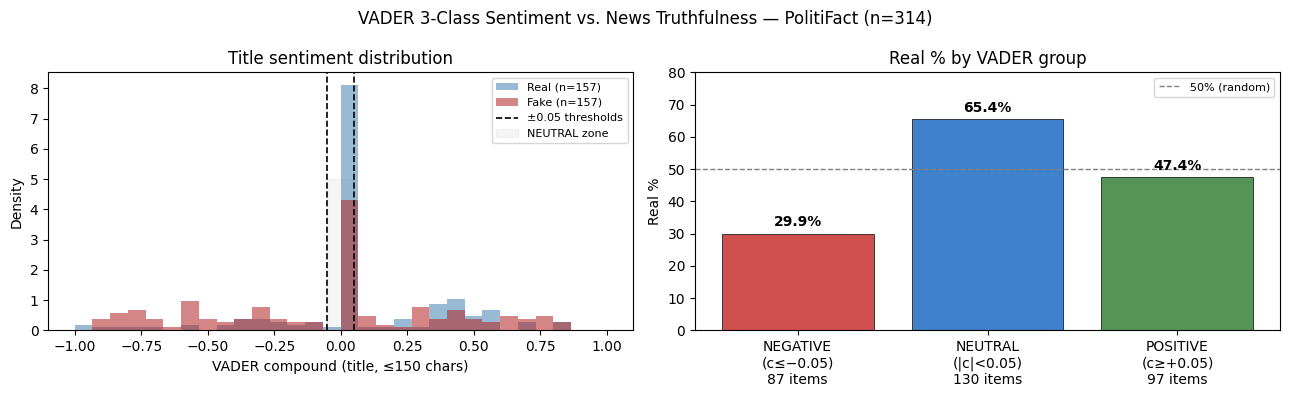

Figure saved → sentiment_distribution_v2.png


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# ── Load news text and news-item ordering ─────────────────────────────────────
with open('data/pol_news_text.pkl', 'rb') as fh:
    text_dict = pickle.load(fh)
with open('data/pol_news_list.txt') as fh:
    news_list = [ln.strip() for ln in fh]

graph_labels = np.load('data/politifact/raw/graph_labels.npy')
real_mask    = graph_labels == 0
fake_mask    = graph_labels == 1
assert len(news_list) == len(graph_labels), 'News list / label count mismatch'

# ── VADER scoring (title only — first ~150 chars) ────────────────────────────
sia = SentimentIntensityAnalyzer()

def score_vader_title(news_list, text_dict):
    out = []
    for nid in news_list:
        text  = text_dict.get(nid, '')
        chunk = text.split('\n')[0][:150]
        out.append(sia.polarity_scores(chunk)['compound'])
    return np.array(out)

print('Scoring article titles with VADER...')
title_compounds = score_vader_title(news_list, text_dict)
print(f'Done. n={len(title_compounds)}')

# ── 3-class masks (standard VADER thresholds) ────────────────────────────────
neg_mask = title_compounds <= -0.05
neu_mask = (title_compounds > -0.05) & (title_compounds < 0.05)
pos_mask = title_compounds >= 0.05

# ── Distribution summary table ────────────────────────────────────────────────
print()
print(f'{"Group":<40}  {"n":>5}  {"real%":>7}  {"fake%":>7}')
print('-' * 65)
group_defs = [
    ('NEGATIVE  (compound <= -0.05)',    neg_mask),
    ('NEUTRAL   (-0.05 < compound < +0.05)', neu_mask),
    ('POSITIVE  (compound >= +0.05)',    pos_mask),
    ('TOTAL',                            np.ones(len(graph_labels), dtype=bool)),
]
for name, mask in group_defs:
    n = mask.sum()
    if n > 0:
        r_pct = real_mask[mask].mean() * 100
        f_pct = 100 - r_pct
        print(f'{name:<40}  {n:>5}  {r_pct:>6.1f}%  {f_pct:>6.1f}%')
print()
print(f'Compound mean — real: {title_compounds[real_mask].mean():.3f}   '
      f'fake: {title_compounds[fake_mask].mean():.3f}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('VADER 3-Class Sentiment vs. News Truthfulness — PolitiFact (n=314)', fontsize=12)

bins = np.linspace(-1, 1, 31)

# Left: title compound histogram with 3-class threshold lines
ax = axes[0]
ax.hist(title_compounds[real_mask], bins=bins, alpha=0.55, color='steelblue',
        label='Real (n=157)', density=True)
ax.hist(title_compounds[fake_mask], bins=bins, alpha=0.55, color='firebrick',
        label='Fake (n=157)', density=True)
ax.axvline(-0.05, color='black', lw=1.2, ls='--', label='±0.05 thresholds')
ax.axvline( 0.05, color='black', lw=1.2, ls='--')
ax.fill_betweenx([0, 5], -0.05,  0.05, alpha=0.08, color='gray', label='NEUTRAL zone')
ax.set_xlabel('VADER compound (title, ≤150 chars)')
ax.set_ylabel('Density')
ax.set_title('Title sentiment distribution')
ax.legend(fontsize=8)
ax.set_ylim(0, None)

# Right: real% by 3-class group
ax = axes[1]
glabels  = ['NEGATIVE\n(c≤−0.05)\n87 items', 'NEUTRAL\n(|c|<0.05)\n130 items', 'POSITIVE\n(c≥+0.05)\n97 items']
gmasks   = [neg_mask, neu_mask, pos_mask]
real_pcts = [real_mask[m].mean() * 100 for m in gmasks]
gcolors   = ['#C62828', '#1565C0', '#2E7D32']
bars = ax.bar(glabels, real_pcts, color=gcolors, alpha=0.82, edgecolor='k', lw=0.6)
ax.axhline(50, color='gray', ls='--', lw=1, label='50% (random)')
for b, p in zip(bars, real_pcts):
    ax.text(b.get_x() + b.get_width() / 2, p + 1.5, f'{p:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Real %')
ax.set_ylim(0, 80)
ax.set_title('Real % by VADER group')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('sentiment_distribution_v2.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure saved → sentiment_distribution_v2.png')


## Phase 4 — Hyperedge Construction

`get_sentiment_edges(scheme)` applies standard VADER ±0.05 thresholds to
`title_compounds` (computed in Phase 3). Five schemes: three single-group
ablations plus two combinations.


In [ ]:
from utils.hypergraph import Hypergraph

builder         = Hypergraph(args)
base_hyperedges = builder.get_hyperedges()
print(f'Base hyperedges: {len(base_hyperedges)}')

# Pre-build the three group lists once (used by every scheme)
_neg = [int(i) for i, c in enumerate(title_compounds) if c <= -0.05]
_neu = [int(i) for i, c in enumerate(title_compounds) if -0.05 < c < 0.05]
_pos = [int(i) for i, c in enumerate(title_compounds) if c >= 0.05]

def get_sentiment_edges(scheme):
    """
    Return a list of hyperedges using standard VADER 3-class thresholds
    (±0.05) applied to title_compounds (Phase 3).

    Schemes
    -------
    'neg_only'  : [NEGATIVE]                 ablation — 87 items, 70% fake
    'neu_only'  : [NEUTRAL]                  ablation — 130 items, 65% real
    'pos_only'  : [POSITIVE]                 ablation — 97 items, 52% fake (noise)
    'neg_neu'   : [NEGATIVE, NEUTRAL]        skip noisy POSITIVE
    '3class'    : [NEGATIVE, NEUTRAL, POSITIVE]  full 3-class
    """
    if   scheme == 'neg_only': return [_neg]
    elif scheme == 'neu_only': return [_neu]
    elif scheme == 'pos_only': return [_pos]
    elif scheme == 'neg_neu':  return [_neg, _neu]
    elif scheme == '3class':   return [_neg, _neu, _pos]
    else: raise ValueError(f'Unknown sentiment scheme: {scheme!r}')


# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'\n{"Scheme":<12}  {"# edges":>7}  {"group sizes"}')
print('-' * 45)
for sc in ('neg_only', 'neu_only', 'pos_only', 'neg_neu', '3class'):
    edges = get_sentiment_edges(sc)
    sizes = ' + '.join(str(len(e)) for e in edges)
    print(f'  {sc:<10}  {len(edges):>6}  {sizes}')
print(f'\nGroup totals: NEG={len(_neg)}  NEU={len(_neu)}  POS={len(_pos)}'
      f'  sum={len(_neg)+len(_neu)+len(_pos)} (should be 314)')


Base hyperedges: 5710

Scheme        # edges  group sizes
---------------------------------------------
  neg_only         1  87
  neu_only         1  130
  pos_only         1  97
  neg_neu          2  87 + 130
  3class           3  87 + 130 + 97

Group totals: NEG=87  NEU=130  POS=97  sum=314 (should be 314)


## Phase 5 — Training Helpers

In [ ]:
from gnn_model.model import HGFND, PropagationEncoder


def build_model_and_ht(cfg, seed):
    """
    Assemble the incidence matrix HT and a freshly seeded model for one config.

    cfg['scheme']:
      None        — base hyperedges only (Baseline / HGFND paper)
      'neg_only'  — base + [NEGATIVE]              ablation
      'neu_only'  — base + [NEUTRAL]               ablation
      'pos_only'  — base + [POSITIVE]              ablation
      'neg_neu'   — base + [NEGATIVE, NEUTRAL]     skip noisy POSITIVE
      '3class'    — base + [NEGATIVE, NEUTRAL, POSITIVE]  full 3-class
    """
    scheme = cfg['scheme']
    if scheme is None:
        all_edges = base_hyperedges
    else:
        all_edges = base_hyperedges + get_sentiment_edges(scheme)

    _, HT_lst, _ = builder.get_adj_matrix(all_edges, nodes_seq)
    HT_t = torch.Tensor(np.array(HT_lst)).float().to(device)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    hg  = HGFND(args)
    mdl = PropagationEncoder(args, hg).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    return mdl, opt, HT_t, len(all_edges)


def run_training(mdl, opt, HT_t, train_idx, val_idx):
    """Train for args.epoch epochs; return best-val checkpoint + history."""
    num_tr   = len(train_idx)
    best_val = 0.0
    best_sd  = None
    tr_losses, val_accs = [], []

    for epoch in range(1, args.epoch + 1):
        mdl.train()
        total = 0.0
        for i in range(0, num_tr, args.batchSize):
            sl  = train_idx[i : i + args.batchSize]
            opt.zero_grad()
            out, _ = mdl(data_nodes, data_edge_index, HT_t, data_batch, sl)
            loss   = F.nll_loss(mdl.compute_scores(out), data_labels[sl])
            loss.backward()
            opt.step()
            total += float(loss) * len(sl)
        tr_losses.append(total / num_tr)

        mdl.eval()
        preds = []
        with torch.no_grad():
            for i in range(0, len(val_idx), args.batchSize):
                sl     = val_idx[i : i + args.batchSize]
                out, _ = mdl(data_nodes, data_edge_index, HT_t, data_batch, sl)
                preds += list(mdl.compute_scores(out).argmax(dim=-1).cpu().numpy())
        va = metrics.accuracy_score(data_labels[val_idx].cpu().numpy(), preds)
        val_accs.append(va)
        if va > best_val:
            best_val = va
            best_sd  = copy.deepcopy(mdl.state_dict())

        if epoch % 20 == 0 or epoch <= 3:
            print(f'  Ep {epoch:03d}  loss={tr_losses[-1]:.4f}  '
                  f'val={va:.4f}  best={best_val:.4f}')

    return best_sd, tr_losses, val_accs, best_val


def do_test(mdl, best_sd, HT_t, test_idx):
    """Load best-val checkpoint and evaluate on held-out test set."""
    mdl.load_state_dict(best_sd)
    mdl.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(test_idx), args.batchSize):
            sl     = test_idx[i : i + args.batchSize]
            out, _ = mdl(data_nodes, data_edge_index, HT_t, data_batch, sl)
            preds += list(mdl.compute_scores(out).argmax(dim=-1).cpu().numpy())
    truth = data_labels[test_idx].cpu().numpy()
    return {
        'accuracy'  : metrics.accuracy_score(truth, preds),
        'f1_macro'  : metrics.f1_score(truth, preds, average='macro'),
        'f1_micro'  : metrics.f1_score(truth, preds, average='micro'),
        'precision' : metrics.precision_score(truth, preds, average='macro'),
        'recall'    : metrics.recall_score(truth, preds, average='macro'),
    }

print('Training helpers ready.')


Training helpers ready.


## Phase 6 — Sweep: 6 Configs × 7 Seeds = 42 Runs


In [ ]:
all_results = {cfg['label']: {'train_losses': [], 'val_accs': [], 'metrics': []}
               for cfg in CONFIGS}

n_tr = int(len(dataset) * 0.2)   # 62 train
n_vl = int(len(dataset) * 0.1)   # 31 val
n_te = len(dataset) - n_tr - n_vl  # 221 test

total_runs = len(SEEDS) * len(CONFIGS)
run_num    = 0

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    tr_set, vl_set, te_set = random_split(dataset, [n_tr, n_vl, n_te])
    train_idx_s = list(tr_set.indices)
    val_idx_s   = list(vl_set.indices)
    test_idx_s  = list(te_set.indices)

    print(f'\n{"#"*65}')
    print(f'SEED {seed}  —  train={len(train_idx_s)}  val={len(val_idx_s)}  test={len(test_idx_s)}')
    print(f'{"#"*65}')

    for cfg in CONFIGS:
        run_num += 1
        lbl = cfg['label']
        print(f'\n{"="*60}')
        print(f'Run {run_num}/{total_runs}  |  {lbl}  |  seed={seed}')
        print(f'{"="*60}')

        mdl, opt, HT_t, n_edges = build_model_and_ht(cfg, seed)
        print(f'Hyperedges: {n_edges}\n')

        best_sd, tr_losses, val_accs, best_val = run_training(
            mdl, opt, HT_t, train_idx_s, val_idx_s)
        test_m = do_test(mdl, best_sd, HT_t, test_idx_s)

        all_results[lbl]['train_losses'].append(tr_losses)
        all_results[lbl]['val_accs'].append(val_accs)
        all_results[lbl]['metrics'].append(test_m)

        print(f'\nBest val acc : {best_val:.4f}')
        print('Test  ->  ' + '  '.join(f'{k}={v:.4f}' for k, v in test_m.items()))

print(f'\n{"ok "*3} All {total_runs} runs complete.')


#################################################################
SEED 42  —  train=62  val=31  test=221
#################################################################

Run 1/42  |  Baseline  |  seed=42
Hyperedges: 5710

  Ep 001  loss=0.6990  val=0.3871  best=0.3871
  Ep 002  loss=0.6871  val=0.3871  best=0.3871
  Ep 003  loss=0.6880  val=0.3871  best=0.3871
  Ep 020  loss=0.6020  val=0.3871  best=0.4194
  Ep 040  loss=0.1923  val=0.8710  best=0.9032
  Ep 060  loss=0.2225  val=0.7742  best=0.9032
  Ep 080  loss=0.1032  val=0.8710  best=0.9032
  Ep 100  loss=0.0537  val=0.8387  best=0.9032
  Ep 120  loss=0.0786  val=0.9032  best=0.9032
  Ep 140  loss=0.1090  val=0.8710  best=0.9032
  Ep 160  loss=0.0181  val=0.8387  best=0.9032
  Ep 180  loss=0.0245  val=0.8710  best=0.9032
  Ep 200  loss=0.0713  val=0.8710  best=0.9032

Best val acc : 0.9032
Test  ->  accuracy=0.9412  f1_macro=0.9411  f1_micro=0.9412  precision=0.9440  recall=0.9414

Run 2/42  |  +NEG only  |  seed=42
Hyperedges: 

## Phase 7 — Training Curves

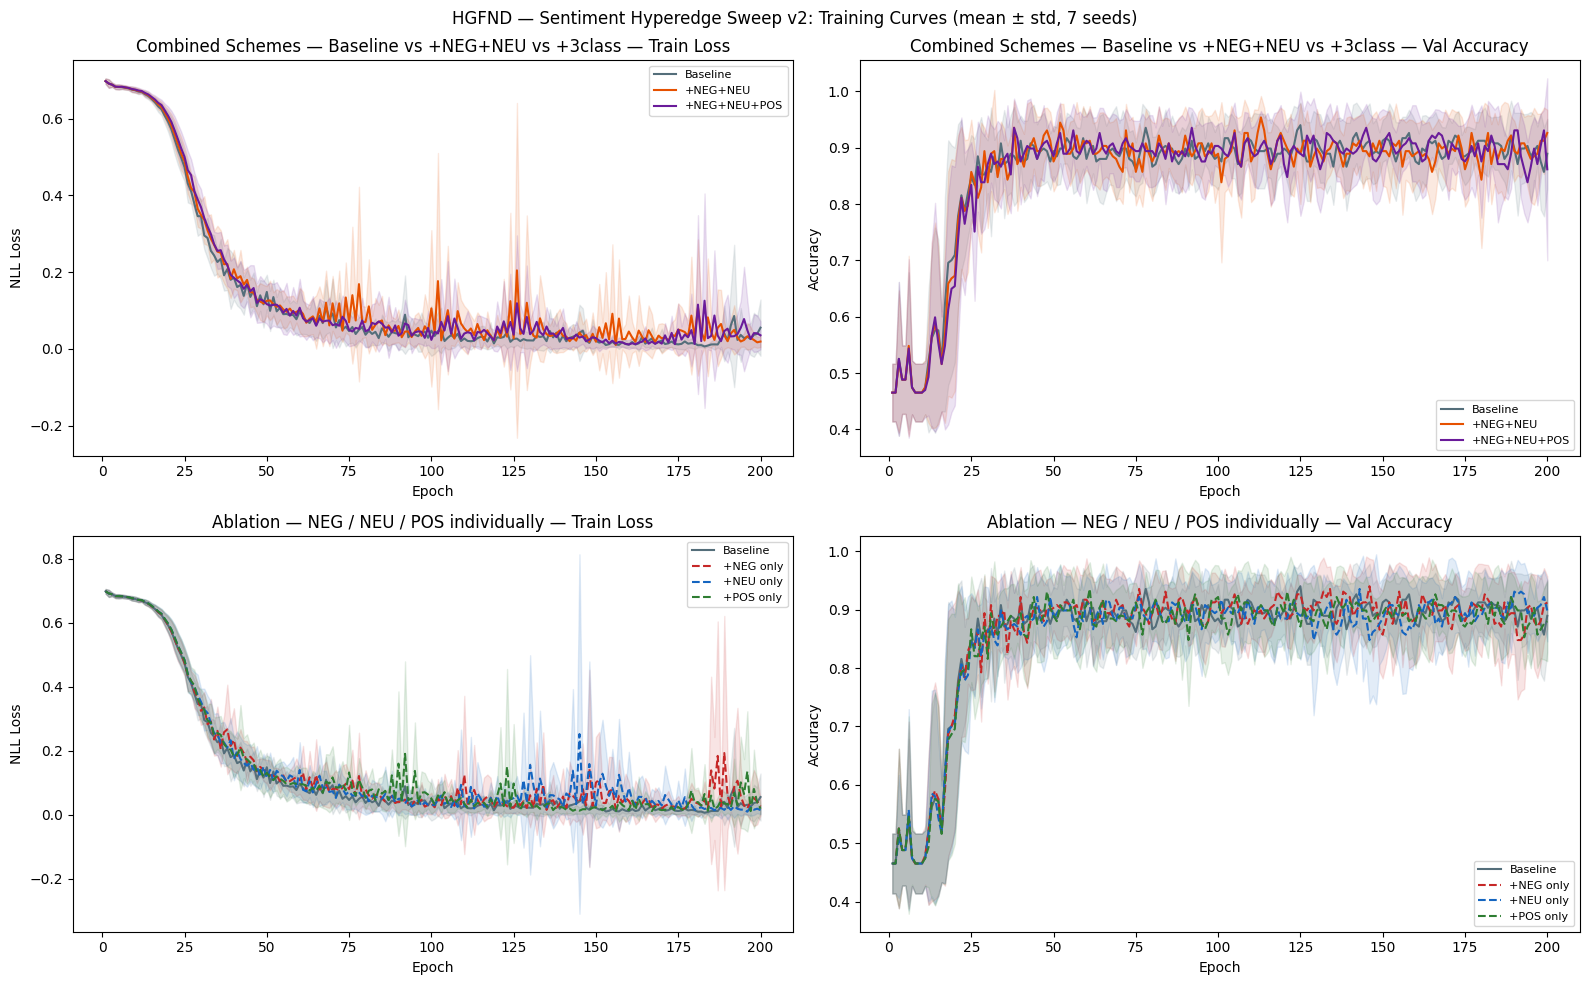

Figure saved -> sentiment_sweep_v2_curves.png


In [ ]:
ep = np.arange(1, EPOCHS + 1)

# Top panel: Baseline vs combined schemes (+NEG+NEU, +NEG+NEU+POS)
panel_top = [c for c in CONFIGS if c['scheme'] in (None, 'neg_neu', '3class')]
# Bottom panel: Baseline vs individual ablations (+NEG, +NEU, +POS)
panel_bot = [c for c in CONFIGS if c['scheme'] in (None, 'neg_only', 'neu_only', 'pos_only')]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'HGFND — Sentiment Hyperedge Sweep v2: Training Curves (mean ± std, 7 seeds)',
    fontsize=12)

for panel, ax_loss, ax_val, title in [
        (panel_top, axes[0, 0], axes[0, 1], 'Combined Schemes — Baseline vs +NEG+NEU vs +3class'),
        (panel_bot, axes[1, 0], axes[1, 1], 'Ablation — NEG / NEU / POS individually'),
]:
    for cfg in panel:
        lbl = cfg['label']
        res = all_results[lbl]
        if not res['train_losses']:
            continue
        tl = np.array(res['train_losses'])
        va = np.array(res['val_accs'])
        ax_loss.plot(ep, tl.mean(0), color=cfg['color'], ls=cfg['ls'], lw=1.5, label=lbl)
        ax_loss.fill_between(ep, tl.mean(0) - tl.std(0), tl.mean(0) + tl.std(0),
                             color=cfg['color'], alpha=0.12)
        ax_val.plot(ep, va.mean(0), color=cfg['color'], ls=cfg['ls'], lw=1.5, label=lbl)
        ax_val.fill_between(ep, va.mean(0) - va.std(0), va.mean(0) + va.std(0),
                            color=cfg['color'], alpha=0.12)
    ax_loss.set_title(f'{title} — Train Loss')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('NLL Loss')
    ax_loss.legend(fontsize=8)
    ax_val.set_title(f'{title} — Val Accuracy')
    ax_val.set_xlabel('Epoch'); ax_val.set_ylabel('Accuracy')
    ax_val.legend(fontsize=8)

plt.tight_layout()
plt.savefig('sentiment_sweep_v2_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure saved -> sentiment_sweep_v2_curves.png')


## Phase 8 — Results Summary

In [ ]:
METRIC_NAMES = ['accuracy', 'f1_macro', 'f1_micro', 'precision', 'recall']

print(f'\n{"Config":<30}  {"acc mean":>9}  {"± std":>7}  '
      f'{"Δ acc":>7}  {"f1_mac":>7}  {"f1_mic":>7}')
print('-' * 75)

baseline_mean = None
for cfg in CONFIGS:
    lbl = cfg['label']
    res = all_results[lbl]
    if not res['metrics']:
        print(f'  {lbl:<28}  (no results)')
        continue
    accs = [m['accuracy'] for m in res['metrics']]
    f1m  = [m['f1_macro'] for m in res['metrics']]
    f1mi = [m['f1_micro'] for m in res['metrics']]
    mean_acc = np.mean(accs)
    std_acc  = np.std(accs)
    if baseline_mean is None:
        baseline_mean = mean_acc
    delta = mean_acc - baseline_mean
    sign  = '+' if delta >= 0 else ''
    print(f'  {lbl:<28}  {mean_acc:.4f}    ±{std_acc:.4f}  '
          f'{sign}{delta:.4f}  {np.mean(f1m):.4f}  {np.mean(f1mi):.4f}')
print()
print('Δ acc  = mean test accuracy vs. Baseline (positive = improvement)')


Config                           acc mean    ± std    Δ acc   f1_mac   f1_mic
---------------------------------------------------------------------------
  Baseline                      0.9024    ±0.0266  +0.0000  0.9020  0.9024
  +NEG only                     0.9076    ±0.0268  +0.0052  0.9072  0.9076
  +NEU only                     0.9030    ±0.0233  +0.0006  0.9027  0.9030
  +POS only                     0.9056    ±0.0295  +0.0032  0.9052  0.9056
  +NEG+NEU                      0.9069    ±0.0198  +0.0045  0.9066  0.9069
  +NEG+NEU+POS                  0.9114    ±0.0219  +0.0090  0.9112  0.9114

Δ acc  = mean test accuracy vs. Baseline (positive = improvement)


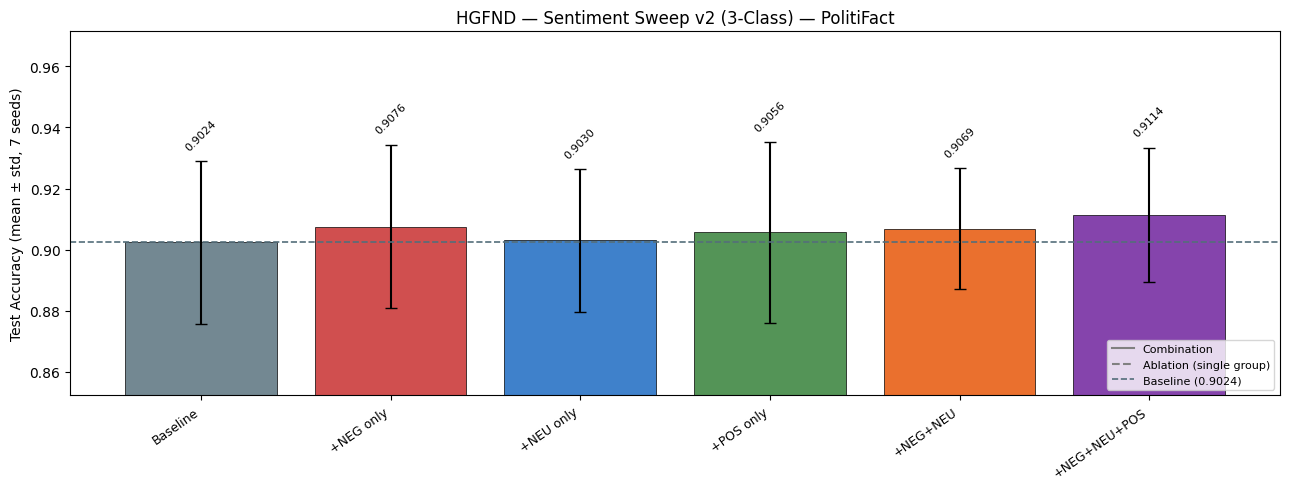

Figure saved -> sentiment_sweep_v2_bars.png


In [ ]:
# ── Accuracy bar chart ────────────────────────────────────────────────────────
means  = []
stds   = []
labels = []
colors = []
for cfg in CONFIGS:
    lbl  = cfg['label']
    res  = all_results[lbl]
    accs = [m['accuracy'] for m in res['metrics']] if res['metrics'] else [0]
    means.append(np.mean(accs))
    stds.append(np.std(accs))
    labels.append(lbl)
    colors.append(cfg['color'])

x      = np.arange(len(CONFIGS))
bl_acc = means[0]  # Baseline

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(x, means, color=colors, alpha=0.82, edgecolor='k', lw=0.6,
              yerr=stds, capsize=4)
ax.axhline(bl_acc, color='#546E7A', ls='--', lw=1.2, label=f'Baseline ({bl_acc:.4f})')
for b, m, s in zip(bars, means, stds):
    ax.text(b.get_x() + b.get_width() / 2, m + s + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=8, rotation=45)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Test Accuracy (mean ± std, 7 seeds)')
ax.set_title('HGFND — Sentiment Sweep v2 (3-Class) — PolitiFact')
ax.set_ylim(max(0, min(means) - 0.05), min(1, max(means) + 0.06))

from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0], [0], color='gray', ls='-',  lw=1.5, label='Combination'),
    Line2D([0], [0], color='gray', ls='--', lw=1.5, label='Ablation (single group)'),
]
ax.legend(handles=legend_lines + [ax.get_legend_handles_labels()[0][0]],
          labels=['Combination', 'Ablation (single group)', f'Baseline ({bl_acc:.4f})'],
          loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('sentiment_sweep_v2_bars.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure saved -> sentiment_sweep_v2_bars.png')


In [ ]:
from scipy import stats

sep  = '=' * 74
sep2 = '-' * 74

def get_accs(lbl):
    return [m['accuracy'] for m in all_results[lbl]['metrics']]

baseline_accs = get_accs('Baseline')
b_mean        = float(np.mean(baseline_accs))

print(sep)
print('HGFND SENTIMENT SWEEP v2 — STATISTICAL SUMMARY')
print(sep)
print(f'\n  Baseline (7 seeds): {b_mean:.4f} +/- {np.std(baseline_accs):.4f}')
print(f'  Seeds  : {SEEDS}')
print(f'  Groups : NEG={len(_neg)} (70% fake)  NEU={len(_neu)} (65% real)  POS={len(_pos)} (52% fake)\n')

# ── Q1: Does the best combination beat baseline? ─────────────────────────────
print('Q1. Do 3-class sentiment hyperedges improve over baseline?')
for lbl in ('+NEG+NEU', '+NEG+NEU+POS'):
    accs  = get_accs(lbl)
    delta = np.mean(accs) - b_mean
    t, p  = stats.ttest_ind(accs, baseline_accs)
    sign  = '+' if delta >= 0 else ''
    if   delta >  0.005: verdict = 'IMPROVEMENT'
    elif delta < -0.005: verdict = 'REGRESSION'
    else:                verdict = 'NEGLIGIBLE'
    print(f'   {lbl:<18}  acc={np.mean(accs):.4f}  delta={sign}{delta:.4f}  '
          f't={t:.2f}  p={p:.3f}  [{verdict}]')

# ── Q2: Does dropping noisy POS help or hurt? ────────────────────────────────
print()
print('Q2. Does dropping the noisy POSITIVE group help? (+NEG+NEU vs +NEG+NEU+POS)')
accs_nn  = get_accs('+NEG+NEU')
accs_3c  = get_accs('+NEG+NEU+POS')
t, p     = stats.ttest_ind(accs_nn, accs_3c)
winner   = '+NEG+NEU' if np.mean(accs_nn) >= np.mean(accs_3c) else '+NEG+NEU+POS'
print(f'   +NEG+NEU      : {np.mean(accs_nn):.4f}')
print(f'   +NEG+NEU+POS  : {np.mean(accs_3c):.4f}')
print(f'   -> {winner} wins  (t={t:.2f}  p={p:.3f})')
print(f'   (Expected: +NEG+NEU — POSITIVE group is 52% fake, near-random)')

# ── Q3: Ablation — which single group contributes most? ──────────────────────
print()
print('Q3. Ablation — which single group has the most impact?')
ablation_configs = ['+NEG only', '+NEU only', '+POS only']
ablation_results = []
for lbl in ablation_configs:
    accs  = get_accs(lbl)
    delta = np.mean(accs) - b_mean
    ablation_results.append((lbl, np.mean(accs), delta))
    print(f'   {lbl:<12}  acc={np.mean(accs):.4f}  delta={delta:+.4f}')
best_abl = max(ablation_results, key=lambda x: x[1])
print(f'   -> Best ablation: {best_abl[0]}  (delta={best_abl[2]:+.4f})')
print(f'   (Expected: NEG or NEU — POSITIVE group is near-random)')

# ── Full results table ────────────────────────────────────────────────────────
print()
print(sep)
print('FULL RESULTS TABLE')
print(sep2)
print(f'  {"Config":<18}  {"acc":>7}  {"+/-std":>7}  {"delta":>8}  {"f1_mac":>7}  {"f1_mic":>7}  {"verdict"}')
print(sep2)
for cfg in CONFIGS:
    lbl  = cfg['label']
    res  = all_results[lbl]
    accs = [m['accuracy'] for m in res['metrics']] if res['metrics'] else []
    f1ms = [m['f1_macro'] for m in res['metrics']] if res['metrics'] else []
    f1mi = [m['f1_micro'] for m in res['metrics']] if res['metrics'] else []
    if not accs:
        print(f'  {lbl:<18}  (no results)')
        continue
    m = np.mean(accs); s = np.std(accs); d = m - b_mean
    if   d >  0.005: verdict = 'IMPROVEMENT'
    elif d < -0.005: verdict = 'REGRESSION'
    else:            verdict = 'NEGLIGIBLE'
    print(f'  {lbl:<18}  {m:.4f}  +/-{s:.4f}  {d:+.4f}  {np.mean(f1ms):.4f}  {np.mean(f1mi):.4f}  {verdict}')
print(sep)
print()
print('Results at a glance')
print(sep2)
print(f'  {"Config":<18}  {"acc":>6}  {"±std":>6}  {"Δ":>7}  {"verdict"}')
print(sep2)
for cfg in CONFIGS:
    lbl  = cfg['label']
    res  = all_results[lbl]
    accs = [m['accuracy'] for m in res['metrics']] if res['metrics'] else []
    if not accs: continue
    m = np.mean(accs); s = np.std(accs); d = m - b_mean
    dash = '—' if d == 0.0 and lbl == 'Baseline' else f'{d:+.4f}'
    if   d >  0.005: verdict = 'IMPROVEMENT'
    elif d < -0.005: verdict = 'REGRESSION'
    elif lbl == 'Baseline': verdict = '—'
    else:            verdict = 'NEGLIGIBLE'
    print(f'  {lbl:<18}  {m:.4f}  {s:.4f}  {dash:>7}  {verdict}')


HGFND SENTIMENT SWEEP v2 — STATISTICAL SUMMARY

  Baseline (7 seeds): 0.9024 +/- 0.0266
  Seeds  : [42, 2026, 33, 123, 456, 789, 1000]
  Groups : NEG=87 (70% fake)  NEU=130 (65% real)  POS=97 (52% fake)

Q1. Do 3-class sentiment hyperedges improve over baseline?
   +NEG+NEU            acc=0.9069  delta=+0.0045  t=0.33  p=0.744  [NEGLIGIBLE]
   +NEG+NEU+POS        acc=0.9114  delta=+0.0090  t=0.64  p=0.532  [IMPROVEMENT]

Q2. Does dropping the noisy POSITIVE group help? (+NEG+NEU vs +NEG+NEU+POS)
   +NEG+NEU      : 0.9069
   +NEG+NEU+POS  : 0.9114
   -> +NEG+NEU+POS wins  (t=-0.38  p=0.714)
   (Expected: +NEG+NEU — POSITIVE group is 52% fake, near-random)

Q3. Ablation — which single group has the most impact?
   +NEG only     acc=0.9076  delta=+0.0052
   +NEU only     acc=0.9030  delta=+0.0006
   +POS only     acc=0.9056  delta=+0.0032
   -> Best ablation: +NEG only  (delta=+0.0052)
   (Expected: NEG or NEU — POSITIVE group is near-random)

FULL RESULTS TABLE
--------------------------